<a href="https://colab.research.google.com/github/areesha-del/AI-ML-Hands-on/blob/main/CLUSTRING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Clustering**

In [ ]:
import numpy as np
import pandas as pd

# -------------------------------
# Step 0: Dataset
# -------------------------------
points = {
    "A": (2, 3),
    "B": (3, 4),
    "C": (8, 7),
    "D": (9, 8),
    "E": (10, 9)
}

df = pd.DataFrame(points).T
df.columns = ["x", "y"]

# Initial centroids
centroids = {
    "C1": np.array([2, 3], dtype=float),
    "C2": np.array([10, 9], dtype=float)
}

# -------------------------------
# Euclidean Distance
# -------------------------------
def euclidean(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

# -------------------------------
# One K-Means Iteration
# -------------------------------
def kmeans_iteration(data, centroids):
    data = data.copy()  # 🔑 prevents iteration-2 error
    clusters = []

    for _, row in data.iterrows():
        d1 = euclidean(row[["x", "y"]].values, centroids["C1"])
        d2 = euclidean(row[["x", "y"]].values, centroids["C2"])

        clusters.append("C1" if d1 < d2 else "C2")

    data["Cluster"] = clusters

    # Update centroids
    new_centroids = {}
    for c in ["C1", "C2"]:
        new_centroids[c] = data[data["Cluster"] == c][["x", "y"]].mean().values

    return data, new_centroids

# -------------------------------
# Iteration 1
# -------------------------------
print("🔁 Iteration 1")
df, centroids = kmeans_iteration(df, centroids)
print(df)
print("\nCentroids after Iteration 1:")
for k, v in centroids.items():
    print(f"{k}: {v}")

# -------------------------------
# Iteration 2
# -------------------------------
print("\n🔁 Iteration 2")
df, centroids = kmeans_iteration(df, centroids)
print(df)
print("\nCentroids after Iteration 2:")
for k, v in centroids.items():
    print(f"{k}: {v}")


🔁 Iteration 1
    x  y Cluster
A   2  3      C1
B   3  4      C1
C   8  7      C2
D   9  8      C2
E  10  9      C2

Centroids after Iteration 1:
C1: [2.5 3.5]
C2: [9. 8.]

🔁 Iteration 2
    x  y Cluster
A   2  3      C1
B   3  4      C1
C   8  7      C2
D   9  8      C2
E  10  9      C2

Centroids after Iteration 2:
C1: [2.5 3.5]
C2: [9. 8.]


In [ ]:
import numpy as np
import pandas as pd

# -------------------------------
# Dataset
# -------------------------------
points = {
    "A": (2, 3),
    "B": (3, 4),
    "C": (8, 7),
    "D": (9, 8),
    "E": (10, 9)
}

df = pd.DataFrame(points).T
df.columns = ["x", "y"]

# Initial centroids
initial_centroids = {
    "C1": np.array([2, 3], dtype=float),
    "C2": np.array([10, 9], dtype=float)
}

# -------------------------------
# Distance Functions
# -------------------------------
def euclidean(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

def manhattan(p1, p2):
    return np.sum(np.abs(p1 - p2))

# -------------------------------
# K-Means Function (1 iteration)
# -------------------------------
def kmeans(data, centroids, distance_func):
    data = data.copy()
    clusters = []

    for _, row in data.iterrows():
        d1 = distance_func(row[["x", "y"]].values, centroids["C1"])
        d2 = distance_func(row[["x", "y"]].values, centroids["C2"])
        clusters.append("C1" if d1 < d2 else "C2")

    data["Cluster"] = clusters

    new_centroids = {}
    for c in ["C1", "C2"]:
        new_centroids[c] = data[data["Cluster"] == c][["x", "y"]].mean().values

    return data, new_centroids

# -------------------------------
# Euclidean Distance Clustering
# -------------------------------
print("📌 K-Means using Euclidean Distance")
df_euclid, centroids_e = kmeans(df, initial_centroids, euclidean)
print(df_euclid)
print("\nFinal Centroids (Euclidean):")
for k, v in centroids_e.items():
    print(f"{k}: {v}")

# -------------------------------
# Manhattan Distance Clustering
# -------------------------------
print("\n📌 K-Means using Manhattan Distance")
df_manhattan, centroids_m = kmeans(df, initial_centroids, manhattan)
print(df_manhattan)
print("\nFinal Centroids (Manhattan):")
for k, v in centroids_m.items():
    print(f"{k}: {v}")

# -------------------------------
# Compare Assignments
# -------------------------------
comparison = pd.DataFrame({
    "Euclidean Cluster": df_euclid["Cluster"],
    "Manhattan Cluster": df_manhattan["Cluster"]
})

print("\n📊 Cluster Assignment Comparison")
print(comparison)


📌 K-Means using Euclidean Distance
    x  y Cluster
A   2  3      C1
B   3  4      C1
C   8  7      C2
D   9  8      C2
E  10  9      C2

Final Centroids (Euclidean):
C1: [2.5 3.5]
C2: [9. 8.]

📌 K-Means using Manhattan Distance
    x  y Cluster
A   2  3      C1
B   3  4      C1
C   8  7      C2
D   9  8      C2
E  10  9      C2

Final Centroids (Manhattan):
C1: [2.5 3.5]
C2: [9. 8.]

📊 Cluster Assignment Comparison
  Euclidean Cluster Manhattan Cluster
A                C1                C1
B                C1                C1
C                C2                C2
D                C2                C2
E                C2                C2


Dataset:
    x  y
A   2  3
B   3  4
C   8  7
D   9  8
E  10  9

Pairwise Euclidean Distance Matrix:
       A     B     C     D      E
A   0.00  1.41  7.21  8.60  10.00
B   1.41  0.00  5.83  7.21   8.60
C   7.21  5.83  0.00  1.41   2.83
D   8.60  7.21  1.41  0.00   1.41
E  10.00  8.60  2.83  1.41   0.00


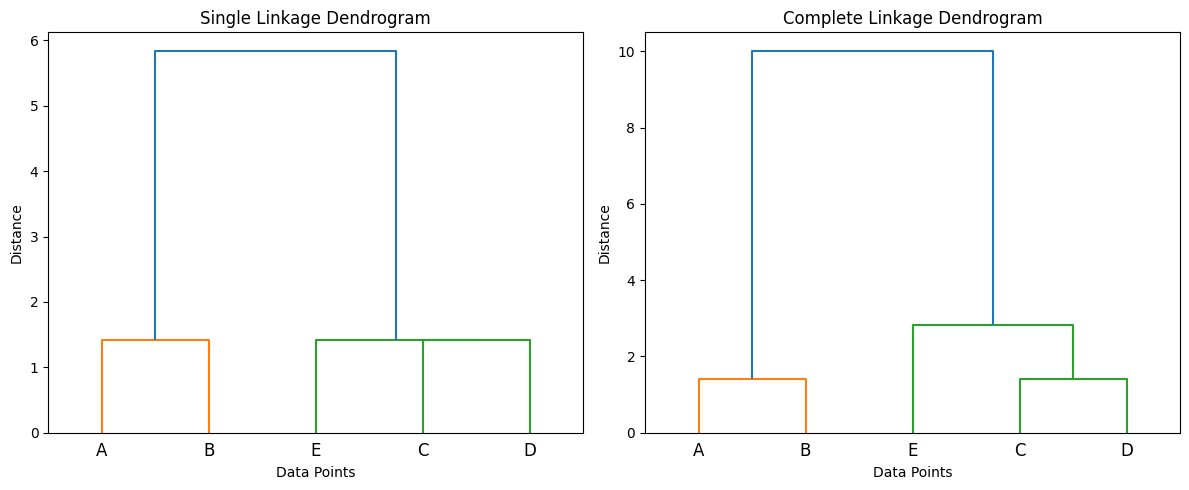

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

# ----------------------------------
# Step 1: Dataset
# ----------------------------------
points = {
    "A": (2, 3),
    "B": (3, 4),
    "C": (8, 7),
    "D": (9, 8),
    "E": (10, 9)
}

df = pd.DataFrame(points).T
df.columns = ["x", "y"]

print("Dataset:")
print(df)

# ----------------------------------
# Step 2: Pairwise Distance Matrix
# ----------------------------------
distance_matrix = squareform(pdist(df.values, metric="euclidean"))

dist_df = pd.DataFrame(
    distance_matrix,
    index=df.index,
    columns=df.index
)

print("\nPairwise Euclidean Distance Matrix:")
print(dist_df.round(2))

# ----------------------------------
# Step 3: Hierarchical Clustering
# ----------------------------------

# Single Linkage
single_linkage = linkage(df.values, method="single", metric="euclidean")

# Complete Linkage
complete_linkage = linkage(df.values, method="complete", metric="euclidean")

# ----------------------------------
# Step 4: Dendrograms
# ----------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
dendrogram(single_linkage, labels=df.index.tolist())
plt.title("Single Linkage Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.subplot(1, 2, 2)
dendrogram(complete_linkage, labels=df.index.tolist())
plt.title("Complete Linkage Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()
